In [2]:
import matplotlib.pyplot as plt
import os
import csv
import random
import numpy as np
from scipy.stats import norm 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter
import datetime
import re
import casadi as ca
#import l4casadi as l4c
import time

2025-07-24 10:22:05.305792: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 10:22:05.305838: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 10:22:05.305871: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 10:22:05.316877: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-24 10:22:06.771640: W tensorflow/compiler/

In [8]:
import os
import csv
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm

# --- Utility to find latest dataset folder -------------------------------

def find_latest_directory(base_dir):
    subdirs = [d for d in os.listdir(base_dir)
               if os.path.isdir(os.path.join(base_dir, d))]
    latest = max(subdirs,
                 key=lambda d: os.path.getmtime(os.path.join(base_dir, d)))
    return os.path.join(base_dir, latest)

def find_latest_dataset_directory(polar, fixed_view, ripe):
    script_dir = os.getcwd()
    base = os.path.join(script_dir, "datasets",
                        "polar" if polar else "cartesian",
                        "fixed_view" if fixed_view else "variable_view",
                        "ripe"       if ripe else "raw")
    return find_latest_directory(base)

# --- Data loading & augmentation ------------------------------------------

def generate_augmented_data(X, Y, augment_frac=0.2):
    N = len(X)
    n_aug = int(N * augment_frac)
    synthetic = []
    synth_labels = []
    yaw_choices = np.radians([30, -30, 60, -60, 90, -90, 180, -180])
    r_min = np.linalg.norm(X[:, :2], axis=1).min()
    r_max = np.linalg.norm(X[:, :2], axis=1).max()

    for _ in range(n_aug):
        θ = random.uniform(-np.pi, np.pi)
        r = random.choice([random.uniform(0, r_min),
                           random.uniform(r_max, r_max + 5)])
        dx, dy = r * np.cos(θ), r * np.sin(θ)
        yaw = random.choice(yaw_choices)
        synthetic.append([dx, dy, np.sin(yaw), np.cos(yaw)])
        # here we assume scalar Y; adjust if vector
        synth_labels.append([0.5, 0.5])  
    return np.vstack([X, synthetic]), np.vstack([Y, synth_labels])

def load_data(polar=False, fixed_view=False, ripe=True,
              augment=True, validation_split=0.35):
    # 1) Load raw CSV
    folder = find_latest_dataset_directory(polar, fixed_view, ripe)
    path = os.path.join(folder, "SurrogateDatasetCNN.csv")
    print(f"Loading data from {path}")

    X, Y = [], []
    with open(path) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            dx, dy, yaw, _, val_raw, val_ripe, _ = map(float, row)
            label = val_ripe if ripe else val_raw
            X.append([dx, dy, np.sin(yaw), np.cos(yaw)])
            Y.append([label, 1-label] if ripe else [1-label, label])

    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float).reshape(-1, 2)


    # 2) Augment
    if augment:
        X, Y = generate_augmented_data(X, Y, augment_frac=0.2)

    # 3) To tensors
    Xt = torch.from_numpy(X).float()
    Yt = torch.from_numpy(Y).float().reshape(-1, 2)

    ds  = TensorDataset(Xt, Yt)

    # 4) Split
    n_val = int(len(ds) * validation_split)
    n_tr  = len(ds) - n_val
    return random_split(ds, [n_tr, n_val])

# --- A simpler 2‐layer MLP -----------------------------------------------

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=4, hidden=128, output_dim=1,
                 filter_radius=4.5, filter_steepness=10.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, output_dim),
        )
        # register as tensor buffers so TorchScript sees them as Tensors
        self.register_buffer('filter_radius',
                             torch.tensor(filter_radius, dtype=torch.float32))
        self.register_buffer('filter_steepness',
                             torch.tensor(filter_steepness, dtype=torch.float32))

    def forward(self, x):
        logits = self.net(x)

        if x.dim() == 1:
            r = torch.norm(x[:2], p=2)
        else:
            r = torch.norm(x[:, :2], p=2, dim=1, keepdim=True)

        # now both sides of the subtraction are Tensors
        w = torch.sigmoid(self.filter_steepness * (self.filter_radius - r))

        filtered_logits = logits * w
        return F.softmax(filtered_logits, dim=-1)
# --- Training loop -------------------------------------------------------

def train_model():
    # Hyper‐params
    batch_size = 32
    epochs     = 50
    lr         = 1e-3
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Datasets
    train_ds, val_ds = load_data(polar=False,
                                 fixed_view=False,
                                 ripe=True,
                                 augment=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)

    # Model / optimizer / loss
    model     = SimpleMLP(input_dim=4, hidden=64, output_dim=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val = float('inf')
    for epoch in range(1, epochs+1):
        # ——— Train —————————————————————————————
        model.train()
        t_loss = 0.0
        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(train_loader)

        # ——— Validate ————————————————————————————
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]"):
                xb, yb = xb.to(device), yb.to(device)
                out    = model(xb)
                v_loss += criterion(out, yb).item()
        v_loss /= len(val_loader)

        print(f"Epoch {epoch:2d} | Train: {t_loss:.4f} | Val: {v_loss:.4f}")

        # ——— Save best ———————————————————————————
        if v_loss < best_val:
            best_val = v_loss
            torch.save(model.state_dict(), "best_simple_mlp.pth")
            print(f"→ New best model (val {v_loss:.4f}) saved.")

if __name__ == "__main__":
    torch.manual_seed(0)
    train_model()


Epoch 1/50 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/50 [Train]:  41%|████      | 32/79 [00:00<00:00, 316.89it/s]

Loading data from /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/ripe/2025-03-29_20-28-15/SurrogateDatasetCNN.csv


Epoch 2/50 [Train]:  35%|███▌      | 28/79 [00:00<00:00, 278.60it/s]

Epoch  1 | Train: 0.0022 | Val: 0.0019
→ New best model (val 0.0019) saved.


...

Epoch 48 | Train: 0.0007 | Val: 0.0006
→ New best model (val 0.0006) saved.


Epoch 50/50 [Train]:  38%|███▊      | 30/79 [00:00<00:00, 290.58it/s]

Epoch 49 | Train: 0.0007 | Val: 0.0007


Epoch 50/50 [Val]: 100%|██████████| 43/43 [00:00<00:00, 922.15it/s]

Epoch 50 | Train: 0.0007 | Val: 0.0007


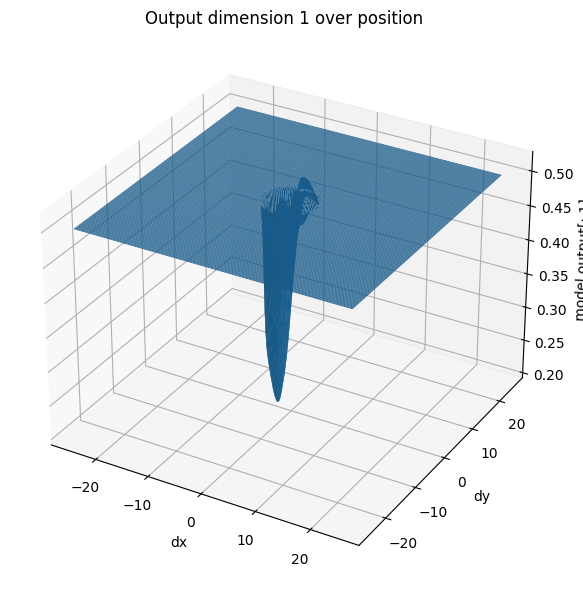

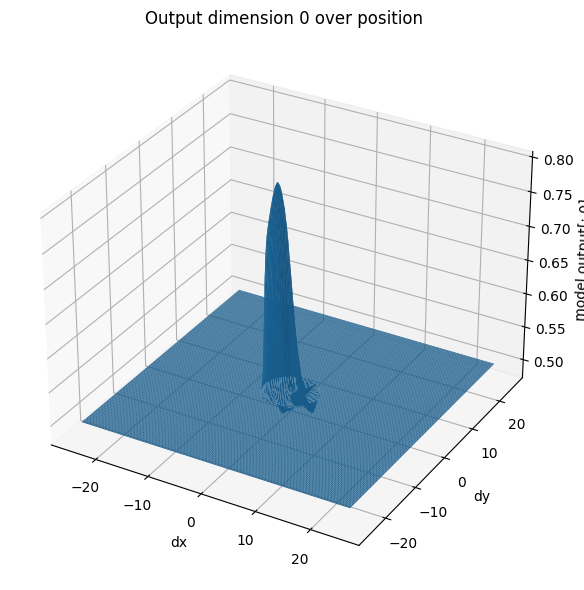

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_model_surface(
    model,
    output_idx=0,
    xlim=(-10,10),
    ylim=(-10,10),
    resolution=200,
    device=None
):
    """
    3D surface of model’s output[:, output_idx] over (dx, dy).
    - output_idx: which output dimension to plot (0 or 1)
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    XX, YY = np.meshgrid(xs, ys, indexing='xy')
    YAW = np.arctan2(-YY, -XX)

    # build input [dx,dy,sin(yaw),cos(yaw)]
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    siny = np.sin(YAW).ravel()[:,None]
    cosy = np.cos(YAW).ravel()[:,None]
    X_in = np.hstack([pts, siny, cosy])
    Xt = torch.from_numpy(X_in).float().to(device)

    # predict in batches, selecting the chosen output dimension
    preds = []
    bs = 4096
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            out = model(Xt[i:i+bs]).cpu().numpy()
            # out has shape (N,2) — pick one column
            preds.append(out[:, output_idx])
    Z = np.concatenate(preds).reshape(resolution, resolution)

    # plot
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(XX, YY, Z, rstride=1, cstride=1, linewidth=0, antialiased=True)
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_zlabel(f"model output[:,{output_idx}]")
    ax.set_title(f"Output dimension {output_idx} over position")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # make sure your model was built with output_dim=2!
    model = SimpleMLP(input_dim=4, hidden=64, output_dim=2).to(device)
    model.load_state_dict(torch.load("best_simple_mlp.pth", map_location=device))

    # plot only the first head
    delta_size = 25
    plot_model_surface(model, output_idx=1, xlim=(-delta_size,delta_size), ylim=(-delta_size,delta_size), resolution=200, device=device)
    plot_model_surface(model, output_idx=0, xlim=(-delta_size,delta_size), ylim=(-delta_size,delta_size), resolution=200, device=device)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
import l4casadi as l4c

ENTROPY_DECAY = -2 # decay exponent for future entropy
ENTROPY_SCALE = -40
SIGMOID_STEEPNESS = 10.0
DIST_THRESHOLD = 9.0

N = 10
dt = 1.0
T = dt * N
nx = 3
n_control = nx
n_state = nx * 2
initial_randomic = True

sensing_radius_sq = 3.0**2

# Constants for cost weights
Q_dist = 1e-3

# Attraction term
W_entropy =1.0
# Control effort penalty
W_xy_accel = 1e-3
W_theta_accel = 1e-3

class NeuralMPC:
    def __init__(self, g_nn, run_dir=None, num_trees=5):
        np.random.seed(30)
        [self.g_nn_ripe, self.g_nn_raw] = g_nn

        self.current_robot_state = None

        self.trees_pos = self._get_trees_poses(num_trees)
        self.lb, self.ub = self.get_domain(self.trees_pos)
        
        self.current_robot_state = self.generate_random_initial_state(margin=1.5).flatten() if initial_randomic else  np.array([self.lb[0] + 1.0, (self.lb[1]+self.ub[1])/2.0, 0.0])
        
        self.num_total_trees = self.trees_pos.shape[0]
        self.true_tree_states = np.random.choice([1, 1], size=(self.num_total_trees))
        self.latest_trees_scores = np.full((self.num_total_trees, 2), 0.5) 
        self.beliefs_k = ca.DM.ones(self.num_total_trees, 2) * 0.5

        self.entropy_func = self.entropy_f(self.num_total_trees)
        self.bayes_func = self.bayes_multiclass(self.num_total_trees, 2)

        self.save_folder = run_dir if run_dir is not None else "./simulation_results"
        os.makedirs(self.save_folder, exist_ok=True)


    def _get_trees_poses(self, num_trees, space=4.0):
        coords = np.arange(0.1, num_trees * space, space)
        grid_x, grid_y = np.meshgrid(coords, coords)
        return np.column_stack((grid_x.ravel(), grid_y.ravel()))

    def _robot_state_update(self):
        return self.current_robot_state + np.random.uniform(0.001, nx)

    def _tree_scores_sensor(self):
        for i in range(self.num_total_trees):
            diff_robot_tree = self.trees_pos[i, :2] - np.array(self.current_robot_state).flatten()[:2]
            drone_yaw = np.array(self.current_robot_state).flatten()[2]

            angle_robot_tree = np.arctan2(diff_robot_tree[1],diff_robot_tree[0])
            angle_align = np.cos(angle_robot_tree)*np.cos(drone_yaw) + np.sin(angle_robot_tree)*np.sin(drone_yaw)

            dist_sq = np.sum((diff_robot_tree)**2)
            value = angle_align * 0.75 if dist_sq < sensing_radius_sq and (angle_align >= np.cos(np.pi/6.0)) else 0.5

            self.latest_trees_scores[i, ~(self.true_tree_states[i])] = value
            self.latest_trees_scores[i, self.true_tree_states[i]] = 1-value

    @staticmethod
    def get_domain(tree_positions):
        return  [np.min(tree_positions[:, 0]), np.min(tree_positions[:, 1])], \
                [np.max(tree_positions[:, 0]), np.max(tree_positions[:, 1])]

    @staticmethod
    def kin_model(nx_pose, dt): # nx_pose is 3 (x,y,theta)
        nx_full = nx_pose * 2 # Full state [px,py,pw,vx,vy,vw] = 6
        nu = nx_pose          # Control [ax,ay,aw] = 3
        
        x_sym = ca.SX.sym('x', nx_full)
        u_sym = ca.SX.sym('u', nu)
        
        px, py, pw, vx, vy, vw = [x_sym[i] for i in range(nx_full)]
        ax, ay, aw = [u_sym[i] for i in range(nu)]
        
        x_dot = ca.vertcat(vx, vy, vw, ax, ay, aw)
        f_continuous = ca.Function('f_cont', [x_sym, u_sym], [x_dot])
        
        k1 = f_continuous(x_sym, u_sym)
        k2 = f_continuous(x_sym + dt / 2 * k1, u_sym)
        k3 = f_continuous(x_sym + dt / 2 * k2, u_sym)
        k4 = f_continuous(x_sym + dt * k3, u_sym)
        x_next = x_sym + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        
        F = ca.Function('F', [x_sym, u_sym], [x_next])
        return F

    @staticmethod
    def bayes_multiclass(n_targets, n_classes):
        prior = ca.MX.sym("prior", n_targets, n_classes)
        likelihood = ca.MX.sym("likelihood", n_targets, n_classes)

        unnorm = prior * likelihood
        norm = ca.sum1(unnorm) if n_targets == 1 else ca.repmat(ca.sum2(unnorm), 1, n_classes)
        posterior = unnorm / norm 

        return ca.Function("bayes_multiclass", [prior, likelihood], [posterior])

    @staticmethod
    def entropy_f(num_targets):
        p = ca.MX.sym(f'input_entropy_f{num_targets}_dim', num_targets, 2)
        eps = 1e-8
        p_clipped = ca.fmax(eps, ca.fmin(1 - eps, p))
        entropy_per_target = -ca.sum2( p_clipped * (ca.log(p_clipped)/ca.log(2)) )
        return ca.Function(f'entropy_f_{num_targets}_dim', [p], [entropy_per_target])

    def mpc_opt(self, x0_full_state, steps_N):
        opti = ca.Opti()
        F_dynamics = self.kin_model(nx, dt)

        X = opti.variable(n_state, steps_N + 1)
        U = opti.variable(n_control, steps_N)
        
        P_X0_full = opti.parameter(n_state)
        P_TargetLambdas = opti.parameter(self.num_total_trees, 2)

        cost_total = 0
        cost_control_effort = 0
        attraction = 0
        cost_entropy = 0
        
        lambda_evolution_over_horizon = [P_TargetLambdas]
        nn_input_batch_over_horizon = []
        dist_array = []
        
        entropies = [self.entropy_func(lambda_evolution_over_horizon[0])]
        mask = ca.gt(entropies[0], 0.02)

        # Initial condition
        opti.subject_to(X[:, 0] == P_X0_full)

        # Dynamics, bounds, and costs over the horizon
        for i in range(steps_N):
            # State bounds (position, velocity)
            opti.subject_to(opti.bounded(self.lb[0] - 3.0, X[0, i], self.ub[0] + 3.0))    # x pos
            opti.subject_to(opti.bounded(self.lb[1] - 3.0, X[1, i], self.ub[1] + 3.0))    # y pos
            opti.subject_to(opti.bounded(-3*np.pi, X[2, i], +3*np.pi))          # theta
            
            opti.subject_to(opti.bounded(-1.75, X[3:5, i], 1.75))               # vx, vy
            opti.subject_to(opti.bounded(-np.pi/4, X[5, i], np.pi/4))           # vtheta

            # Control bounds (acceleration)
            opti.subject_to(opti.bounded(-5.0, U[0:2, i], 5.0))                 # ax, ay
            opti.subject_to(opti.bounded(-np.pi, U[2, i], np.pi))               # atheta
            
            # System dynamics
            opti.subject_to(X[:, i + 1] == F_dynamics(X[:, i], U[:, i]))
                                  
            # Collision avoidance with OBSTACLE trees
            safe_distance_sq = 1.25**2
            for j in range(self.num_total_trees):
                obs_j_pos = self.trees_pos[j, :]
                dist_sq_obs = ca.sumsqr(X[:2, i+1] - obs_j_pos.T)
                opti.subject_to(dist_sq_obs >= safe_distance_sq)
            
            cost_control_effort = cost_control_effort + \
                                  W_xy_accel * ca.sumsqr(U[:2, i]) + \
                                  W_theta_accel * ca.sumsqr(U[2, i])

            current_nn_input_step_i = []
            
            for j in range(self.num_total_trees):
                target_j_pos = self.trees_pos[j, :]
                diff_robot_to_target = X[:2, i + 1] - target_j_pos.T
                dist_array.append(ca.if_else(mask[j], ca.sumsqr(diff_robot_to_target), 1e20))
                robot_abs_heading = X[2, i+1] 

                # extract and encode heading as sin & cos
                yaw = X[2, i + 1]                                       # 1×1
                sin_yaw = ca.sin(yaw)                                   # 1×1
                cos_yaw = ca.cos(yaw)                                   # 1×1

                # now build the 1×4 input [dx, dy, sin(yaw), cos(yaw)]
                nn_input_for_tree_j = ca.horzcat(
                    diff_robot_to_target.T,   # 1×2
                    sin_yaw,                  # 1×1
                    cos_yaw                   # 1×1
                )
                current_nn_input_step_i.append(nn_input_for_tree_j)
            
            min_d2 = dist_array[0]
            for d2 in dist_array[1:]:
                min_d2 = ca.fmin(min_d2, d2)
            attraction += Q_dist * min_d2
            
            nn_input_batch_over_horizon.append(ca.vcat(current_nn_input_step_i))

        # Batched inference
        nn_full_batch_input = ca.vcat(nn_input_batch_over_horizon)
        surrogate_output_ripe = self.g_nn_ripe(nn_full_batch_input)
        surrogate_output_raw = self.g_nn_raw(nn_full_batch_input)

        # Extend initial lambdas for processing (L0 has N_target_trees elements)
        L0_ext = ca.vcat([P_TargetLambdas for _ in range(steps_N)])

        # Deadzone boundaries
        sel = L0_ext[:, 0] >= L0_ext[:, 1]
        col1 = ca.if_else(sel, surrogate_output_ripe[:,0],  surrogate_output_ripe[:,1])
        col2 = ca.if_else(sel, surrogate_output_raw[:,0],   surrogate_output_raw[:,1])

        surrogate_output =  surrogate_output_ripe

        for i in range(steps_N):
            start_idx = i * self.num_total_trees
            end_idx = (i + 1) * self.num_total_trees
            obs_k_for_step_i = surrogate_output[start_idx:end_idx,:]
            lambda_next = self.bayes_func(lambda_evolution_over_horizon[-1], obs_k_for_step_i)
            lambda_evolution_over_horizon.append(lambda_next)
            entropies.append(self.entropy_func(lambda_next))
            cost_entropy += ca.exp(ENTROPY_DECAY*i) * ca.sum1(entropies[-1])
        
        # attraction modulation via sigmoid based on initial dist
        sigmoid = 1/(1+ca.exp(-SIGMOID_STEEPNESS*(min_d2-DIST_THRESHOLD)))
        mod_attr = attraction * sigmoid

        # total objective: control + attraction - info
        cost_total = 1.0 * cost_entropy  + cost_control_effort
        opti.minimize(cost_total)

        # IPOPT options (removed HSL specific parts for wider compatibility)
        options = {
            "ipopt": {
                #"tol": 1e-5, # Relaxed tol for faster eval
                "warm_start_init_point": "yes",
                "print_level": 0, # Suppress IPOPT output
                "sb": "yes", # Suppress license messages
                "max_iter": 500, # Reduced max_iter
                "hessian_approximation":'limited-memory',
                #"mu_strategy": "monotone",
            },
            "print_time": False
        }
        opti.solver("ipopt", options)

        # Set initial values for parameters
        opti.set_value(P_X0_full, x0_full_state)
        opti.set_value(P_TargetLambdas, self.beliefs_k)
        param_inputs_for_func = [P_X0_full, P_TargetLambdas]
        decision_var_inputs_for_func = [opti.x, opti.lam_g]
        outputs_for_func = [U[:, 0], X, opti.x, opti.lam_g]

        try:
            sol = opti.solve()
            u_sol = sol.value(U[:, 0])
            x_traj_sol = sol.value(X)
            x_dec_sol = sol.value(opti.x) # Full decision variable vector
            lam_g_sol = sol.value(opti.lam_g) # Lagrangian multipliers for constraints
        except RuntimeError as e:
            print(f"IPOPT solve failed: {e}")

        # Create function AFTER first solve
        mpc_step_func = opti.to_function("mpc_step", 
                                         param_inputs_for_func + decision_var_inputs_for_func, 
                                         outputs_for_func)
        
        return (mpc_step_func,
                ca.DM(u_sol),
                ca.DM(x_traj_sol),
                ca.DM(x_dec_sol),
                ca.DM(lam_g_sol))

    def generate_random_initial_state(self, margin=1.5):
        max_attempts = 100
        for _ in range(max_attempts):
            x = np.random.uniform(self.lb[0] + margin, self.ub[0] - margin)
            y = np.random.uniform(self.lb[1] + margin, self.ub[1] - margin)
            valid = True
            for tree_pos_xy in self.trees_pos[:, :2]:
                if np.linalg.norm(np.array([x, y]) - tree_pos_xy) < margin:
                    valid = False
                    break
            if valid:
                theta = np.random.uniform(-np.pi, np.pi)
                return np.array([x, y, theta]).reshape(-1,1)
        # Fallback if no valid state found
        print("Warning: Could not find a valid random initial state away from trees. Using a default.")
        return np.array([self.lb[0] + margin, self.lb[1] + margin, 0.0]).reshape(-1,1)


    def run_simulation(self, max_sim_time_sec=120):
        F_dynamics = self.kin_model(nx, dt)

        # Initialize robot state
        initial_pose_xy_theta = self._robot_state_update()
        print(f"Simulation starting from: {initial_pose_xy_theta}")
        
        # Full state: [x, y, theta, vx, vy, vtheta]
        current_velocities_vx_vy_vtheta = ca.DM.zeros(nx) 
        current_full_state_x_k = ca.vertcat(ca.DM(initial_pose_xy_theta), current_velocities_vx_vy_vtheta)

        # Simulation data logging
        all_predicted_trajectories = []
        lambda_history_all_trees = []
        entropy_history_total = []
        mpc_step_durations = []
        actual_pose_history = []
        sim_time_history = []

        sim_start_wall_time = time.time()
        current_sim_logical_time = 0.0
        
        mpciter = 0
        
        is_first_mpc_solve = True

        # Store previous MPC solution for warm start
        prev_mpc_decision_vars_sol = None
        prev_mpc_lagrangian_multipliers_sol = None
        mpc_solver_function = None

        loop_condition = True
        
        max_iterations = int(max_sim_time_sec / dt)

        while loop_condition and mpciter < max_iterations:
            loop_iter_start_wall_time = time.time()
            current_sim_logical_time = loop_iter_start_wall_time - sim_start_wall_time
            print(f"\nMPC Iteration: {mpciter}, Sim Time: {current_sim_logical_time:.2f}s")

            # Update current robot pose (from previous command) for this iteration
            self.current_robot_state = current_full_state_x_k[:nx].full().flatten().tolist()
            actual_pose_history.append(self.current_robot_state)
            sim_time_history.append(current_sim_logical_time)

            # get tree scores
            self._tree_scores_sensor()
            self.beliefs_k = self.bayes_func(self.beliefs_k, ca.DM(self.latest_trees_scores))
            current_entropy_values = self.entropy_func(self.beliefs_k)
            total_current_entropy = ca.sum1(current_entropy_values).full().flatten()[0]
            print(f"Total Entropy: {total_current_entropy:.4f}")
            
            # Check termination condition (all trees low entropy)
            entropy_threshold_for_termination = 0.05 # More relaxed for mock
            if np.all(current_entropy_values.full().flatten() <= entropy_threshold_for_termination):
                print(f"All tree entropies <= {entropy_threshold_for_termination}. Mission complete.")
                loop_condition = False # This will be the last iteration's processing
            
            if not loop_condition and mpciter > 0: # If mission complete, break before next MPC solve
                 break
            
            mpc_solve_start_time = time.time()
            try:
                if is_first_mpc_solve or mpc_solver_function is None:
                    print("Running MPC opt (first step / cold start)...")
                    mpc_solver_function, u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = self.mpc_opt(
                        current_full_state_x_k, steps_N=N
                    )
                    is_first_mpc_solve = False
                    print("MPC cold start finished.")
                else:
                    print("Running MPC step (warm start)...")
                    # Prepare parameters for the mpc_solver_function
                    param_values = [current_full_state_x_k, 
                                    self.beliefs_k,
                                    prev_mpc_decision_vars_sol,
                                    prev_mpc_lagrangian_multipliers_sol
                                   ]
                    
                    u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = mpc_solver_function(
                        *(param_values)
                    )
                    print("MPC warm start finished.")
                
                mpc_step_duration = time.time() - mpc_solve_start_time
                print(f"MPC step duration: {mpc_step_duration:.4f} s")

            except Exception as e:
                print(f"Error during MPC optimization at step {mpciter}: {e}")
                print("!!! MPC Solver Failed - Using Zero Acceleration & Ending Sim !!!")
                u_optimal_first_step = ca.DM.zeros(n_control) 
                x_predicted_traj = ca.repmat(current_full_state_x_k.reshape((-1,1)), 1, N + 1)
                is_first_mpc_solve = True
                loop_condition = False

            # Apply the first optimal control to the system dynamics to get next state
            next_full_state_x_k_plus_1 = F_dynamics(current_full_state_x_k, u_optimal_first_step)
            
            # Update system state for the next iteration
            current_full_state_x_k = next_full_state_x_k_plus_1
            
            mpciter += 1
            
            if time.time() - sim_start_wall_time > max_sim_time_sec:
                print(f"Max simulation wall time {max_sim_time_sec}s reached.")
                loop_condition = False
            
            # Simulate delay for dt (if computation was faster)
            loop_wall_time_elapsed = time.time() - loop_iter_start_wall_time
            sleep_duration = dt - loop_wall_time_elapsed
            if sleep_duration > 0 and loop_condition :
                time.sleep(sleep_duration)
            elif loop_wall_time_elapsed > dt:
                print(f"Warning: Loop iteration {mpciter-1} took {loop_wall_time_elapsed:.3f}s, longer than dt={dt}s")
            
            mpc_step_durations.append(mpc_step_duration)
            lambda_history_all_trees.append(self.beliefs_k.full().flatten().tolist())
            entropy_history_total.append(total_current_entropy)
            all_predicted_trajectories.append(x_predicted_traj[:nx, :].full())

        # --- End of Simulation Loop ---
        total_execution_wall_time = time.time() - sim_start_wall_time
        print(f"\nSimulation Finished. Total wall time: {total_execution_wall_time:.2f}s, Iterations: {mpciter}")

        # Save metrics
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        perf_csv_path = os.path.join(self.save_folder, f"mock_mpc_{timestamp}_performance.csv")
        avg_mpc_step_time = np.mean(mpc_step_durations) if mpc_step_durations else 0
        final_entropy_val = entropy_history_total[-1] if entropy_history_total else "N/A"
        
        # Calculate total distance traveled
        total_distance = 0
        if len(actual_pose_history) > 1:
            poses_np = np.array(actual_pose_history)
            total_distance = np.sum(np.linalg.norm(np.diff(poses_np[:,:2], axis=0), axis=1))

        with open(perf_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Metric", "Value"])
            writer.writerow(["Total Execution Wall Time (s)", total_execution_wall_time])
            writer.writerow(["Total Simulation Logical Time (s)", current_sim_logical_time])
            writer.writerow(["Total MPC Iterations", mpciter])
            writer.writerow(["Average MPC Step Duration (s)", avg_mpc_step_time])
            writer.writerow(["Final Total Entropy", final_entropy_val])
            writer.writerow(["Total Distance Traveled (m)", total_distance])
        print(f"Performance metrics saved to {perf_csv_path}")

        plot_data_csv_path = os.path.join(self.save_folder, f"mock_mpc_{timestamp}_plot_data.csv")
        with open(plot_data_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["tree_positions_x"] + self.trees_pos[:,0].tolist())
            writer.writerow(["tree_positions_y"] + self.trees_pos[:,1].tolist())
            header = ["sim_time", "robot_x", "robot_y", "robot_theta", "total_entropy"]
            for i in range(self.num_total_trees):
                header.append(f"lambda_tree_{i}")
            writer.writerow(header)
            for i in range(len(sim_time_history)):
                row = [sim_time_history[i]] + actual_pose_history[i] + \
                      [entropy_history_total[i]] + lambda_history_all_trees[i]
                writer.writerow(row)
        print(f"Plot data saved to {plot_data_csv_path}")


        return (actual_pose_history, entropy_history_total, sim_time_history, 
                self.trees_pos, mpc_step_durations, lambda_history_all_trees)



In [6]:
pytorch_model = SimpleMLP(input_dim=4, hidden=64, output_dim=2).to(device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

g_nn = []
title = ['ripe_f', 'unripe_f']
for is_ripe in [1, 0]:
    try:
        pytorch_model.load_state_dict(torch.load("best_simple_mlp.pth", map_location=device))
    except Exception as e:
        print(f"Could not load model {model_load_path}. Error: {e}")
    pytorch_model.eval()

    g_nn.append(l4c.L4CasADi(pytorch_model,
                                name=title[is_ripe],
                                batched=True,
                                device='cuda'))

run_directory = "./simulation_results_mock_run1"
number_of_trees_in_sim = 3
max_simulation_seconds = 120

mpc_instance = NeuralMPC(g_nn=g_nn, run_dir=run_directory, num_trees=number_of_trees_in_sim)

print(f"True tree states: {mpc_instance.true_tree_states.flatten()}")

(   sim_actual_pose_history, 
    sim_entropy_history_total, 
    sim_time_points,
    sim_tree_positions,
    sim_mpc_durations,
    sim_lambda_history
) = mpc_instance.run_simulation(max_sim_time_sec=max_simulation_seconds) #, max_iterations=max_mpc_iterations)

print("\nSimulation run finished. Results collected.")
print(f"Number of time points: {len(sim_time_points)}")
if sim_time_points:
    print(f"Final simulation time: {sim_time_points[-1]:.2f}s")
    print(f"Final robot pose: x={sim_actual_pose_history[-1][0]:.2f}, y={sim_actual_pose_history[-1][1]:.2f}, th={sim_actual_pose_history[-1][2]:.2f}")
    print(f"Final total entropy: {sim_entropy_history_total[-1]:.4f}")
if sim_mpc_durations:
    print(f"Average MPC calculation time: {np.mean(sim_mpc_durations):.4f}s")

True tree states: [1 1 1 1 1 1 1 1 1]
Simulation starting from: [6.23646996 3.73948407 4.22788105]

MPC Iteration: 0, Sim Time: 0.00s
Total Entropy: 9.0000
Running MPC opt (first step / cold start)...


/home/pantheon/mpc-drone/ros/venv/lib/python3.9/site-packages/torch/jit/_check.py:177: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


CUDA is available! Using GPU cuda.
CUDA is available! Using GPU cuda.
MPC cold start finished.
MPC step duration: 8.9950 s

MPC Iteration: 1, Sim Time: 9.00s
Total Entropy: 9.0000
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 9.2538 s

MPC Iteration: 2, Sim Time: 18.25s
Total Entropy: 8.8179
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 6.3278 s

MPC Iteration: 3, Sim Time: 24.58s
Total Entropy: 8.4777
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 9.4421 s

MPC Iteration: 4, Sim Time: 34.02s
Total Entropy: 8.2281
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 1.8577 s

MPC Iteration: 5, Sim Time: 35.88s
Total Entropy: 8.0981
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 4.5915 s

MPC Iteration: 6, Sim Time: 40.47s
Total Entropy: 8.0401
Running MPC step (warm start)...
MPC warm start finished.
MPC step duration: 4.9819 s

MPC Iteration

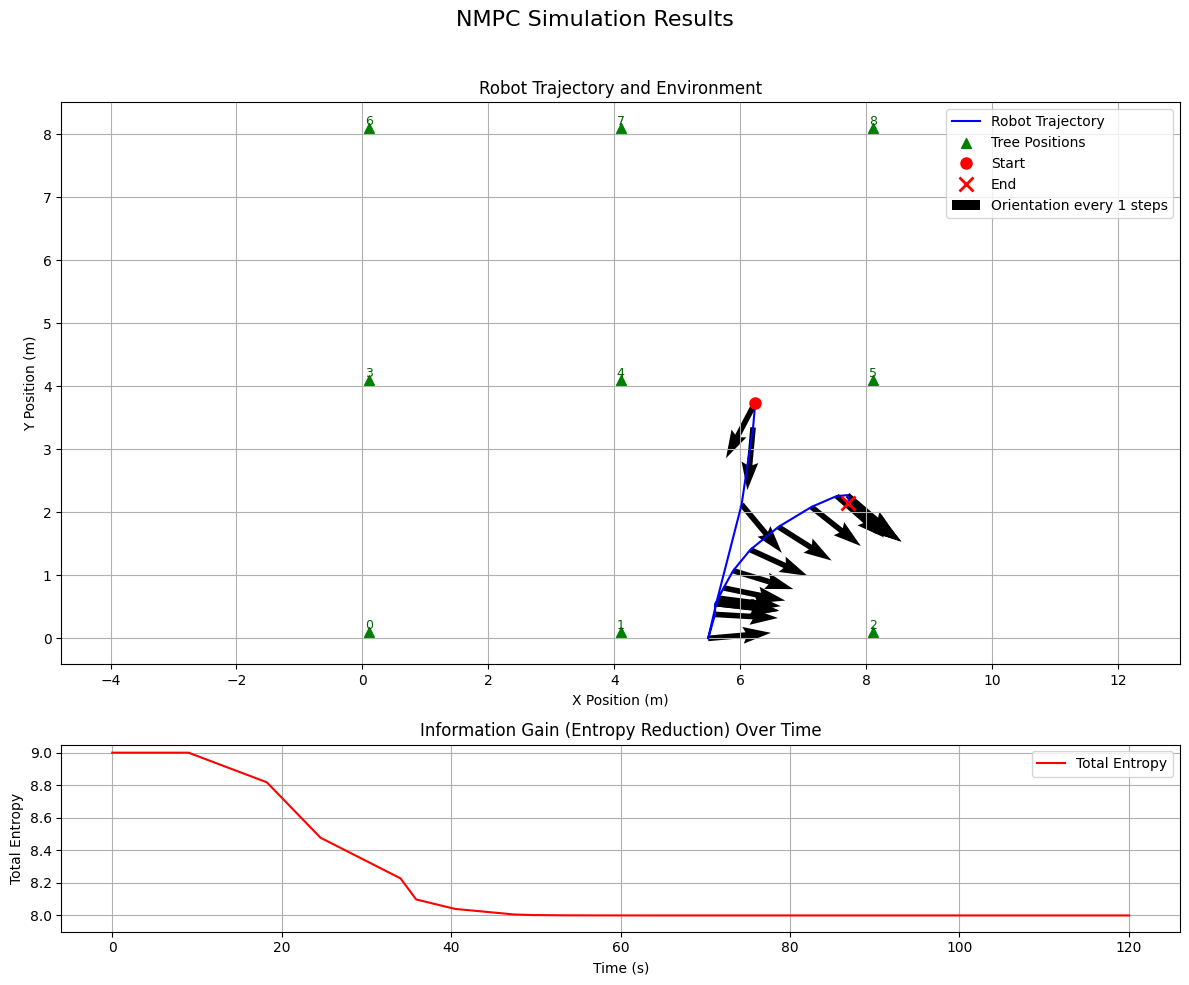

(46, 18)


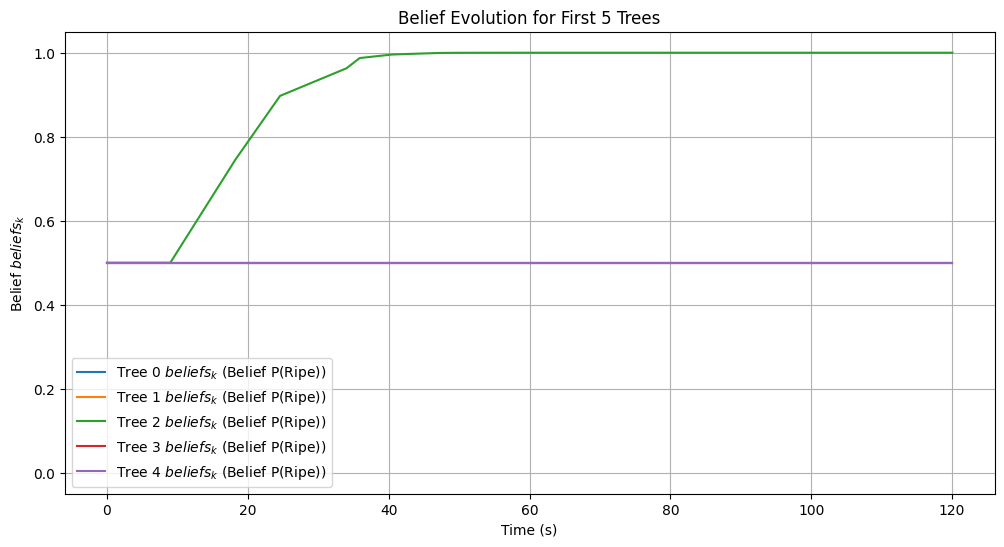

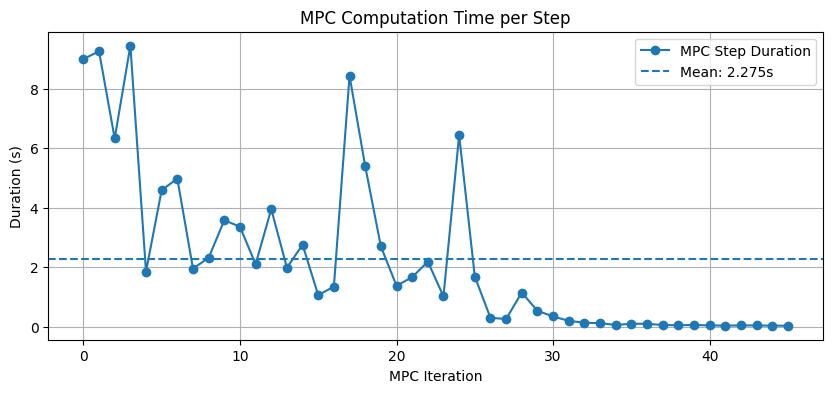

Cell 5: Plotting with Orientation - Complete (if data exists)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Cell 5: Plotting Results with Orientation every 20 steps
if not sim_time_points:
    print("No simulation data to plot.")
else:
    # Extract trajectory data
    poses_array = np.array(sim_actual_pose_history)  # shape (T, 3): [x, y, theta]
    robot_x_coords = poses_array[:, 0]
    robot_y_coords = poses_array[:, 1]
    robot_theta    = poses_array[:, 2]

    fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle('NMPC Simulation Results', fontsize=16)

    # Subplot 1: Robot Trajectory, Orientation, and Tree Positions
    axs[0].plot(robot_x_coords, robot_y_coords, '-b', label="Robot Trajectory")
    axs[0].scatter(sim_tree_positions[:, 0], sim_tree_positions[:, 1], 
                   c='g', marker='^', label="Tree Positions", s=50)
    for i, (tx, ty) in enumerate(sim_tree_positions):
        axs[0].text(tx, ty, str(i), fontsize=9, ha='center', va='bottom', color='darkgreen')

    # Mark start and end points
    axs[0].plot(robot_x_coords[0], robot_y_coords[0], 'ro', markersize=8, label="Start")
    axs[0].plot(robot_x_coords[-1], robot_y_coords[-1], 'rx', markersize=10, mew=2, label="End")

    # Plot orientation arrows every 20 steps
    step = 1
    axs[0].quiver(
        robot_x_coords[::step], robot_y_coords[::step],
        np.cos(robot_theta[::step]), np.sin(robot_theta[::step]),
        angles='xy', scale_units='xy', scale=1, width=0.005,
        label=f"Orientation every {step} steps"
    )

    axs[0].set_xlabel("X Position (m)")
    axs[0].set_ylabel("Y Position (m)")
    axs[0].set_title("Robot Trajectory and Environment")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].axis('equal')  # Ensure aspect ratio is equal

    # Subplot 2: Total Entropy Over Time
    axs[1].plot(sim_time_points, sim_entropy_history_total, '-r', label="Total Entropy")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Total Entropy")
    axs[1].set_title("Information Gain (Entropy Reduction) Over Time")
    axs[1].legend()
    axs[1].grid(True)
    if sim_entropy_history_total:
        min_ent = min(sim_entropy_history_total)
        axs[1].set_ylim(bottom=max(0, min_ent - 0.1))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Optional: Plot individual lambda beliefs for a few trees
    if sim_lambda_history and len(sim_lambda_history[0]) > 0:
        num_trees_to_plot = min(5, mpc_instance.num_total_trees)
        lambda_array = np.array(sim_lambda_history)
        print(lambda_array.shape)
        plt.figure(figsize=(12, 6))
        for i in range(num_trees_to_plot):
            plt.plot(sim_time_points, lambda_array[:, i*2], label=f"Tree {i} $beliefs_k$ (Belief P(Ripe))")
        plt.xlabel("Time (s)")
        plt.ylabel("Belief $beliefs_k$")
        plt.title(f"Belief Evolution for First {num_trees_to_plot} Trees")
        plt.legend()
        plt.grid(True)
        plt.ylim([-0.05, 1.05])
        plt.show()

    # Optional: Plot MPC step durations
    if sim_mpc_durations:
        plt.figure(figsize=(10, 4))
        plt.plot(sim_mpc_durations, marker='o', linestyle='-', label="MPC Step Duration")
        plt.xlabel("MPC Iteration")
        plt.ylabel("Duration (s)")
        plt.title("MPC Computation Time per Step")
        if len(sim_mpc_durations) > 1:
            mean_dur = np.mean(sim_mpc_durations)
            plt.axhline(mean_dur, linestyle='--', label=f"Mean: {mean_dur:.3f}s")
        plt.legend()
        plt.grid(True)
        plt.show()

print("Cell 5: Plotting with Orientation - Complete (if data exists)")
